# Data Profiling — Gaming Compliance & Risk Intelligence Platform

Profiles the **synthetic** transaction data in the Snowflake `STAGING` layer — distributions,
category mix, laundering rate, monthly volume, and data quality. Companion to the reporting
analysis notebook. **Synthetic data only; no credentials in this file.**

Run: `pip install -r ../requirements.txt`, ensure a `~/.snowflake/connections.toml` entry named
`gaming_compliance` (or `SNOWFLAKE_*` env vars), then Run All and commit with outputs.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import snowflake.connector

# No credentials in this file. Uses ~/.snowflake/connections.toml ('gaming_compliance') or SNOWFLAKE_* env vars.
try:
    conn = snowflake.connector.connect(connection_name=os.environ.get("SNOWFLAKE_CONNECTION", "gaming_compliance"))
except Exception:
    kwargs = dict(account=os.environ["SNOWFLAKE_ACCOUNT"], user=os.environ["SNOWFLAKE_USER"],
                  role=os.environ.get("SNOWFLAKE_ROLE", "DATA_ENGINEER"),
                  warehouse=os.environ.get("SNOWFLAKE_WAREHOUSE", "WH_REPORTING"), database="GAMING_COMPLIANCE_DB")
    if os.environ.get("SNOWFLAKE_PASSWORD"): kwargs["password"] = os.environ["SNOWFLAKE_PASSWORD"]
    else: kwargs["authenticator"] = os.environ.get("SNOWFLAKE_AUTHENTICATOR", "externalbrowser")
    conn = snowflake.connector.connect(**kwargs)

for stmt in ("USE ROLE DATA_ENGINEER", "USE WAREHOUSE WH_REPORTING", "USE DATABASE GAMING_COMPLIANCE_DB"):
    conn.cursor().execute(stmt)

def q(sql):
    cur = conn.cursor()
    try: return cur.execute(sql).fetch_pandas_all()
    finally: cur.close()

q("SELECT CURRENT_ROLE() AS ROLE, CURRENT_WAREHOUSE() AS WH, CURRENT_DATABASE() AS DB")

/Users/user/Documents/Portfolio/gaming-compliance-risk-platform-snowflake/.venv/lib/python3.9/site-packages/snowflake/connector/vendored/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


/Users/user/Documents/Portfolio/gaming-compliance-risk-platform-snowflake/.venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


,ROLE,WH,DB
0,DATA_ENGINEER,WH_REPORTING,GAMING_COMPLIANCE_DB


## 1. Transaction overview

In [2]:
ov = q('''SELECT COUNT(*) AS TXNS, MIN(TXN_DATE) AS FIRST_DATE, MAX(TXN_DATE) AS LAST_DATE,
                 ROUND(AVG(AMOUNT),2) AS AVG_AMT, ROUND(MEDIAN(AMOUNT),2) AS MEDIAN_AMT,
                 MIN(AMOUNT) AS MIN_AMT, MAX(AMOUNT) AS MAX_AMT
          FROM STAGING.STG_TRANSACTIONS WHERE IS_VALID''')
ov.T

,0
TXNS,5310
FIRST_DATE,2023-01-01
LAST_DATE,2025-07-03
AVG_AMT,6055.96
MEDIAN_AMT,6042.50
MIN_AMT,25.0
MAX_AMT,12024.0


## 2. Transaction amount distribution
Capped at $15k for readability (a few large values extend beyond).

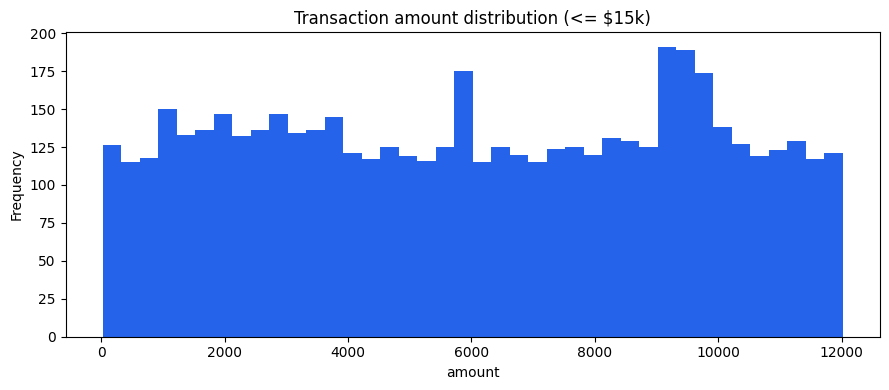

In [3]:
amt = q("SELECT AMOUNT::FLOAT AS AMOUNT FROM STAGING.STG_TRANSACTIONS WHERE IS_VALID AND AMOUNT <= 15000")
ax = amt["AMOUNT"].plot.hist(bins=40, figsize=(9,4), color="#2563eb")
ax.set_title("Transaction amount distribution (<= $15k)"); ax.set_xlabel("amount"); plt.tight_layout(); plt.show()

## 3. Payment-method mix

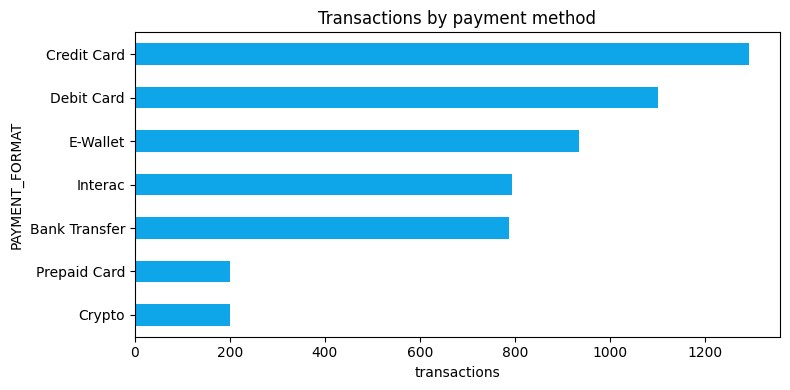

,PAYMENT_FORMAT,TXNS
0,Crypto,200
1,Prepaid Card,201
2,Bank Transfer,788
3,Interac,794
4,E-Wallet,934
5,Debit Card,1100
6,Credit Card,1293


In [4]:
pm = q("SELECT PAYMENT_FORMAT, COUNT(*) AS TXNS FROM STAGING.STG_TRANSACTIONS WHERE IS_VALID GROUP BY 1 ORDER BY TXNS")
ax = pm.plot.barh(x="PAYMENT_FORMAT", y="TXNS", legend=False, figsize=(8,4), color="#0ea5e9")
ax.set_title("Transactions by payment method"); ax.set_xlabel("transactions"); plt.tight_layout(); plt.show()
pm

## 4. Laundering rate by payment method
Share of transactions carrying the synthetic `IS_LAUNDERING` ground-truth label.

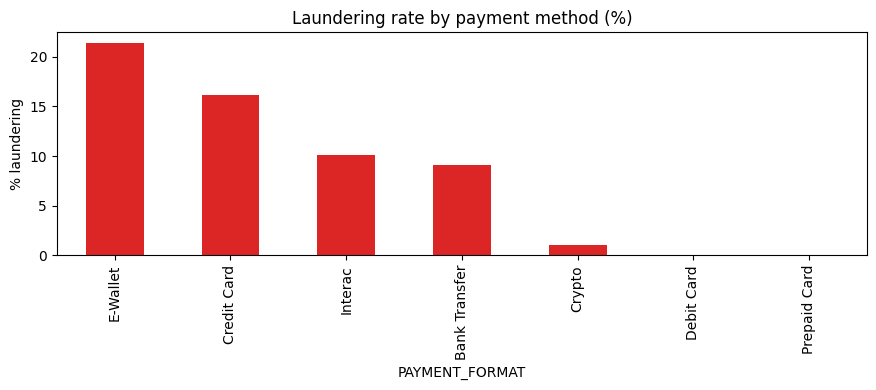

,PAYMENT_FORMAT,TXNS,LAUNDERING,LAUNDER_PCT
0,E-Wallet,934,200,21.4
1,Credit Card,1293,210,16.2
2,Interac,794,80,10.1
3,Bank Transfer,788,72,9.1
4,Crypto,200,2,1.0
5,Debit Card,1100,0,0.0
6,Prepaid Card,201,0,0.0


In [5]:
lr = q('''SELECT PAYMENT_FORMAT, COUNT(*) AS TXNS, SUM(IFF(IS_LAUNDERING,1,0)) AS LAUNDERING,
                 ROUND(100.0*AVG(IFF(IS_LAUNDERING,1,0)),1)::FLOAT AS LAUNDER_PCT
          FROM STAGING.STG_TRANSACTIONS WHERE IS_VALID GROUP BY 1 ORDER BY LAUNDER_PCT DESC''')
ax = lr.plot.bar(x="PAYMENT_FORMAT", y="LAUNDER_PCT", legend=False, figsize=(9,4), color="#dc2626")
ax.set_title("Laundering rate by payment method (%)"); ax.set_ylabel("% laundering"); plt.tight_layout(); plt.show()
lr

## 5. Monthly transaction volume

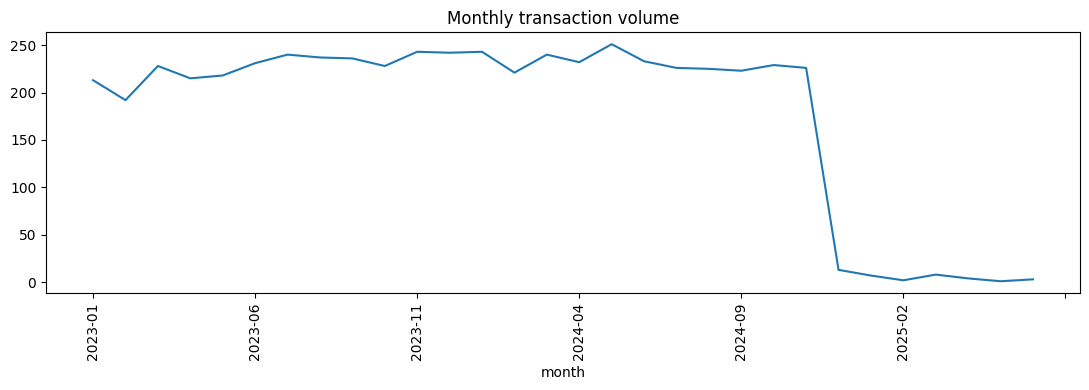

In [6]:
mv = q("SELECT TO_CHAR(TXN_DATE,'YYYY-MM') AS YM, COUNT(*) AS TXNS FROM STAGING.STG_TRANSACTIONS WHERE IS_VALID GROUP BY 1 ORDER BY 1")
ax = mv.plot(x="YM", y="TXNS", legend=False, figsize=(11,4))
ax.set_title("Monthly transaction volume"); ax.set_xlabel("month"); ax.tick_params(axis='x', labelrotation=90)
plt.tight_layout(); plt.show()

## 6. Data quality
Staging flags rows rather than dropping them; on clean synthetic data invalid rows should be 0.

In [7]:
dq = q('''SELECT COUNT(*) AS TOTAL, SUM(IFF(IS_VALID,0,1)) AS INVALID,
                 SUM(IFF(IS_LAUNDERING,1,0)) AS LAUNDERING, SUM(IFF(SANCTIONS_FLAG,1,0)) AS SANCTIONS
          FROM STAGING.STG_TRANSACTIONS''')
dq.T

,0
TOTAL,5310
INVALID,0
LAUNDERING,564
SANCTIONS,250


## Findings

- Transaction amounts cluster below ~$12k with a long tail; a band around $9k–$10k reflects the
  structuring cohort.
- **E-Wallet (21.4%)** and **Credit Card (16.2%)** carry the highest laundering rates — the
  structuring and high-velocity cohorts — while Debit / Prepaid are effectively clean.
- Overall laundering rate is ~**10.6%** (synthetic, planted).
- Data quality: **0 invalid rows** on the synthetic data.
